# Prediction Request ke Heart Disease Model Serving

Notebook ini digunakan untuk menguji dan melakukan prediction request ke sistem machine learning yang telah dijalankan di cloud.

**Model:** Heart Disease Classification  
**Serving URL:** Sesuaikan dengan URL deployment Anda  
**Dataset:** Heart Disease UCI  

## 1. Import Library

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import tensorflow as tf
import base64
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print('TensorFlow version:', tf.__version__)
print('Semua library berhasil diimport!')

TensorFlow version: 2.20.0
Semua library berhasil diimport!


## 2. Konfigurasi URL Serving

Sesuaikan `SERVING_URL` dengan URL deployment yang digunakan.

In [2]:
# ── Konfigurasi ──────────────────────────────────────────────────────
# Ganti URL ini dengan URL deployment cloud Anda
SERVING_URL = 'https://heart-disease-mlops-production.up.railway.app'  # Railway

# Atau gunakan localhost jika berjalan lokal
# SERVING_URL = 'http://localhost:5000'

PREDICT_URL = f'{SERVING_URL}/predict'
HEALTH_URL  = f'{SERVING_URL}/'

print(f'Predict endpoint : {PREDICT_URL}')
print(f'Health endpoint  : {HEALTH_URL}')

Predict endpoint : https://heart-disease-mlops-production.up.railway.app/predict
Health endpoint  : https://heart-disease-mlops-production.up.railway.app/


## 3. Health Check

In [3]:
try:
    resp = requests.get(HEALTH_URL, timeout=10)
    resp.raise_for_status()
    print('Status:', resp.status_code)
    print(json.dumps(resp.json(), indent=2))
except requests.exceptions.ConnectionError:
    print('⚠️  Tidak dapat terhubung ke serving URL.')
    print('Pastikan model serving sudah berjalan.')

Status: 200
{
  "model_dir": "/app/model/heart_disease_model/1",
  "model_loaded": true,
  "status": "healthy"
}


## 4. Mendefinisikan Helper Function

In [4]:
def predict_heart_disease(patient_data: dict) -> dict:
    """
    Melakukan prediksi penyakit jantung untuk satu pasien.

    Args:
        patient_data: Dictionary berisi fitur pasien.

    Returns:
        Dictionary berisi hasil prediksi.
    """
    try:
        response = requests.post(
            PREDICT_URL,
            json=patient_data,
            headers={'Content-Type': 'application/json'},
            timeout=15
        )
        response.raise_for_status()
        return response.json()
    except requests.exceptions.HTTPError as e:
        return {'error': f'HTTP Error: {e}', 'status_code': response.status_code}
    except requests.exceptions.ConnectionError:
        return {'error': 'Connection error – pastikan server berjalan'}
    except Exception as e:
        return {'error': str(e)}


def batch_predict(patients_df: pd.DataFrame) -> pd.DataFrame:
    """
    Melakukan prediksi batch untuk banyak pasien.

    Args:
        patients_df: DataFrame berisi data pasien.

    Returns:
        DataFrame dengan kolom prediksi tambahan.
    """
    results = []
    for _, row in patients_df.iterrows():
        patient = row.to_dict()
        # Hapus kolom target jika ada
        patient.pop('target', None)
        result = predict_heart_disease(patient)
        results.append(result)

    result_df = patients_df.copy()
    result_df['predicted_label']      = [r.get('prediction', None) for r in results]
    result_df['confidence']           = [r.get('confidence', None) for r in results]
    result_df['diagnosis']            = [r.get('diagnosis', None) for r in results]
    result_df['processing_time_ms']   = [r.get('processing_time_ms', None) for r in results]
    return result_df

print('Helper functions siap digunakan!')

Helper functions siap digunakan!


## 5. Single Prediction – Contoh Pasien

In [5]:
# Contoh pasien dengan penyakit jantung (target=1)
patient_positive = {
    'age': 63,
    'sex': 1,
    'cp': 3,
    'trestbps': 145,
    'chol': 233,
    'fbs': 1,
    'restecg': 0,
    'thalach': 150,
    'exang': 0,
    'oldpeak': 2.3,
    'slope': 0,
    'ca': 0,
    'thal': 1
}

print('Data Pasien:')
print(json.dumps(patient_positive, indent=2))
print()

result = predict_heart_disease(patient_positive)
print('Hasil Prediksi:')
print(json.dumps(result, indent=2))

Data Pasien:
{
  "age": 63,
  "sex": 1,
  "cp": 3,
  "trestbps": 145,
  "chol": 233,
  "fbs": 1,
  "restecg": 0,
  "thalach": 150,
  "exang": 0,
  "oldpeak": 2.3,
  "slope": 0,
  "ca": 0,
  "thal": 1
}

Hasil Prediksi:
{
  "confidence": 0.524,
  "diagnosis": "Heart Disease Detected",
  "prediction": 1,
  "processing_time_ms": 2.19
}


In [6]:
# Contoh pasien tanpa penyakit jantung (target=0)
patient_negative = {
    'age': 67,
    'sex': 1,
    'cp': 0,
    'trestbps': 160,
    'chol': 286,
    'fbs': 0,
    'restecg': 0,
    'thalach': 108,
    'exang': 1,
    'oldpeak': 1.5,
    'slope': 1,
    'ca': 3,
    'thal': 2
}

print('Data Pasien:')
print(json.dumps(patient_negative, indent=2))
print()

result = predict_heart_disease(patient_negative)
print('Hasil Prediksi:')
print(json.dumps(result, indent=2))

Data Pasien:
{
  "age": 67,
  "sex": 1,
  "cp": 0,
  "trestbps": 160,
  "chol": 286,
  "fbs": 0,
  "restecg": 0,
  "thalach": 108,
  "exang": 1,
  "oldpeak": 1.5,
  "slope": 1,
  "ca": 3,
  "thal": 2
}

Hasil Prediksi:
{
  "confidence": 0.2883,
  "diagnosis": "No Heart Disease",
  "prediction": 0,
  "processing_time_ms": 2.15
}


## 6. Batch Prediction dari Dataset

In [7]:
# Muat dataset
df = pd.read_csv('josa_pratama-pipeline/data/raw/heart.csv')
print(f'Shape dataset: {df.shape}')
display(df.head())

# Ambil 10 sampel untuk testing
test_samples = df.sample(10, random_state=42).reset_index(drop=True)
print(f'\nMelakukan prediksi untuk {len(test_samples)} sampel...')

Shape dataset: (199, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Melakukan prediksi untuk 10 sampel...


In [8]:
# Batch prediction
results_df = batch_predict(test_samples)

# Tampilkan hasil
display_cols = ['age', 'sex', 'target', 'predicted_label', 'confidence', 'diagnosis']
display(results_df[display_cols])

# Hitung akurasi pada sampel ini
correct = (results_df['target'] == results_df['predicted_label']).sum()
total   = len(results_df)
print(f'\nAkurasi pada sampel: {correct}/{total} = {correct/total:.1%}')

,age,sex,target,predicted_label,confidence,diagnosis
0,62,0,0,0,0.1025,No Heart Disease
1,50,0,1,1,0.5424,Heart Disease Detected
2,57,1,0,0,0.4125,No Heart Disease
3,67,1,0,0,0.3598,No Heart Disease
4,57,0,0,0,0.4245,No Heart Disease
5,54,1,1,1,0.5132,Heart Disease Detected
6,53,1,0,0,0.2513,No Heart Disease
7,46,1,0,0,0.3108,No Heart Disease
8,57,1,0,0,0.4704,No Heart Disease
9,59,1,1,0,0.4035,No Heart Disease



Akurasi pada sampel: 9/10 = 90.0%


## 7. Visualisasi Hasil Prediksi

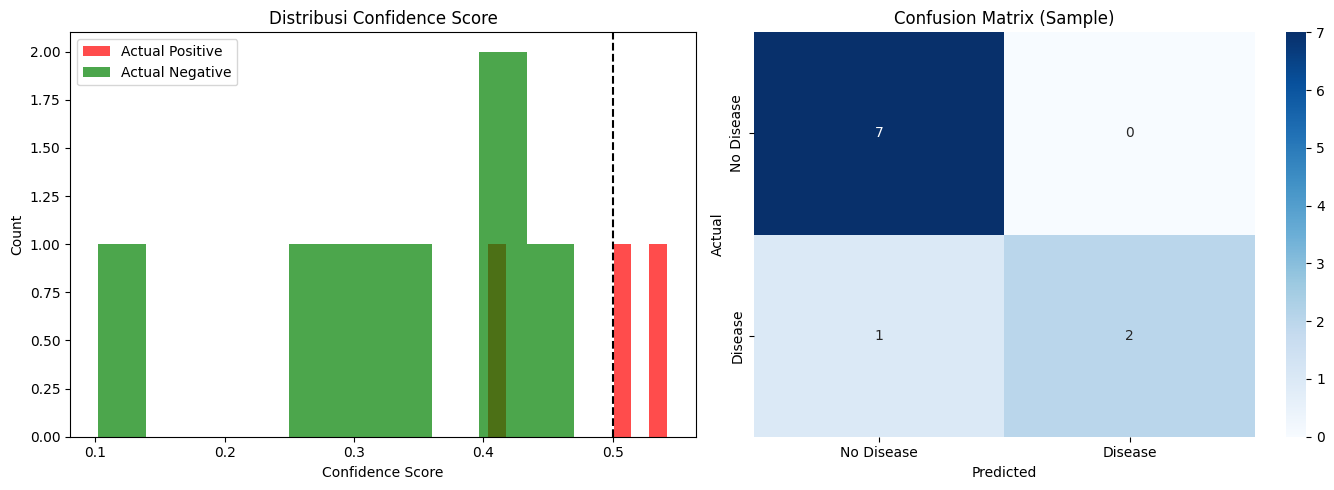

Plot disimpan sebagai prediction_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi confidence score
axes[0].hist(
    results_df[results_df['target'] == 1]['confidence'].dropna(),
    bins=10, alpha=0.7, label='Actual Positive', color='red'
)
axes[0].hist(
    results_df[results_df['target'] == 0]['confidence'].dropna(),
    bins=10, alpha=0.7, label='Actual Negative', color='green'
)
axes[0].set_title('Distribusi Confidence Score')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold=0.5')

# Plot 2: Confusion matrix sederhana
if 'predicted_label' in results_df.columns and results_df['predicted_label'].notna().all():
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(
        results_df['target'],
        results_df['predicted_label'].astype(int)
    )
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
        xticklabels=['No Disease', 'Disease'],
        yticklabels=['No Disease', 'Disease']
    )
    axes[1].set_title('Confusion Matrix (Sample)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai prediction_results.png')

## 8. Performance Benchmark

In [10]:
import time

# Ukur latency untuk 20 request
n_requests = 20
latencies = []

for i in range(n_requests):
    start = time.time()
    result = predict_heart_disease(patient_positive)
    end = time.time()
    if 'error' not in result:
        latencies.append((end - start) * 1000)  # dalam ms

if latencies:
    print(f'📊 Benchmark Results ({len(latencies)} requests):')
    print(f'   Min latency  : {min(latencies):.1f} ms')
    print(f'   Max latency  : {max(latencies):.1f} ms')
    print(f'   Avg latency  : {np.mean(latencies):.1f} ms')
    print(f'   P95 latency  : {np.percentile(latencies, 95):.1f} ms')
    print(f'   Throughput   : {1000/np.mean(latencies):.1f} req/sec')
else:
    print('Tidak ada data latency (pastikan server berjalan)')

📊 Benchmark Results (20 requests):
   Min latency  : 246.8 ms
   Max latency  : 340.6 ms
   Avg latency  : 277.1 ms
   P95 latency  : 329.7 ms
   Throughput   : 3.6 req/sec


## 9. Cek Prometheus Metrics

In [11]:
metrics_url = f'{SERVING_URL}/metrics'

try:
    resp = requests.get(metrics_url, timeout=5)
    # Tampilkan beberapa metric yang relevan
    for line in resp.text.split('\n'):
        if 'heart_disease' in line and not line.startswith('#'):
            print(line)
except Exception as e:
    print(f'Tidak dapat mengambil metrics: {e}')

heart_disease_prediction_requests_total{endpoint="/predict",method="POST",status="200"} 37.0
heart_disease_prediction_requests_created{endpoint="/predict",method="POST",status="200"} 1.789731080811929e+09
heart_disease_prediction_latency_seconds_bucket{le="0.01"} 34.0
heart_disease_prediction_latency_seconds_bucket{le="0.05"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="0.1"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="0.25"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="0.5"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="1.0"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="2.5"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="5.0"} 37.0
heart_disease_prediction_latency_seconds_bucket{le="+Inf"} 37.0
heart_disease_prediction_latency_seconds_count 37.0
heart_disease_prediction_latency_seconds_sum 0.14766597747802734
heart_disease_prediction_latency_seconds_created 1.789730723994995e+09
heart_disease_prediction_confidence_